<a href="https://colab.research.google.com/github/srija936/ai-recruitment-ats-platform/blob/main/Seasonal_Agriculture_Performance_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

Investigate how agricultural performance varies across seasons and identify
meaningful patterns, trends, relationships and differences in the available data.

**Important:** This is a Data Analytics project. No Machine Learning or dashboard
development is required.



##  Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

##  Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.


##  Dataset

The dataset contains farm-level agricultural records covering different seasons,
locations, crops, environmental conditions, farming practices, production, costs,
revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`





In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f'{x:.2f}')

In [6]:
# Load the dataset

import pandas as pd

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [7]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [9]:
#Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [10]:
#Bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [11]:
# Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [12]:
# Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [13]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [14]:
# Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [15]:
# Categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# Data Quality Analysis

In [16]:
# Missing values
missing=df.isnull().sum().sort_values(ascending=False)
missing_percentage=(df.isnull().mean()*100).sort_values(ascending=False)
missing_summary=pd.DataFrame({
    "Missing_Count":missing,
    "Missing_Percentage":missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


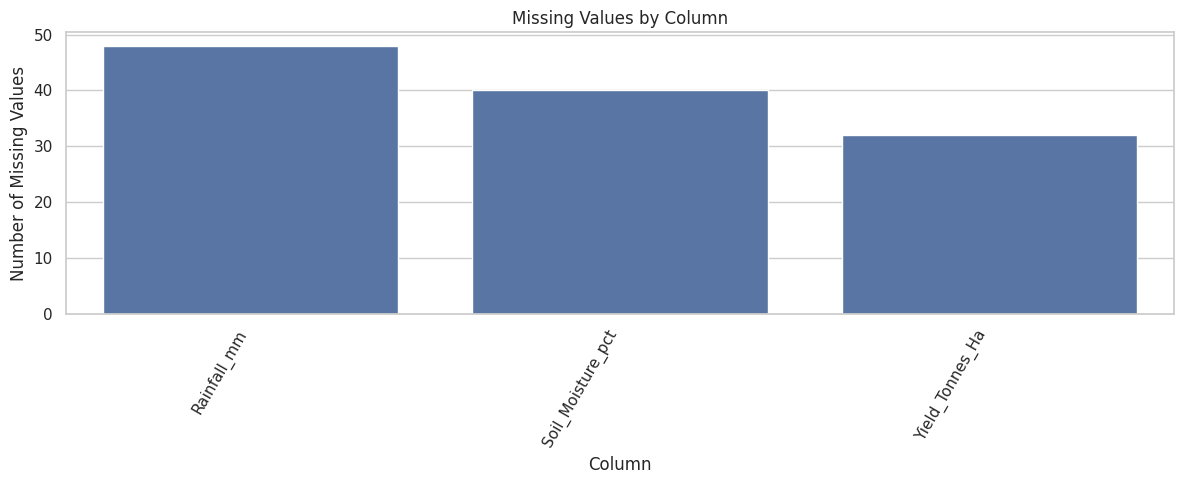

In [17]:
# Visualize missing values

plt.figure(figsize=(12, 5))

missing_plot = missing[missing > 0]

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [18]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [19]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [20]:
# Check data types again

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [21]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [22]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


## Missing Value Treatment

Possible approaches:

- Remove records only when justified.
- Fill numerical values using an appropriate statistic when appropriate.
- Fill categorical values using a suitable category or method.
- Clearly document why the chosen approach is reasonable

In [39]:


numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [40]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


# Statistical Analysis

In [41]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20,1315.20,460.40
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [42]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [43]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])

season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44850.91 25793.00 30301.56      531804.41 524840.00   
Rabi                 44747.97 26041.00 30309.56      513836.58 506733.00   
Zaid                 44212.03 25749.50 30086.23      543976.73 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298487.69   710719.06 520196.00 708710.37  178914.65  38808.00   
Rabi   288386.89   601526.05 438156.00 584545.52   87689.47  -3187.00   
Zaid   297576.86   519171.90 373700.50 509524.55  -24804.82 -62144.00   

                 Water_Used_m3                 Water_Efficiency_t_per_1000m3  \
      

# Univariate Analysis

Univariate analysis examines one variable at a time.
The objective is to understand distributions, frequencies,
central tendency and variability of individual variables.

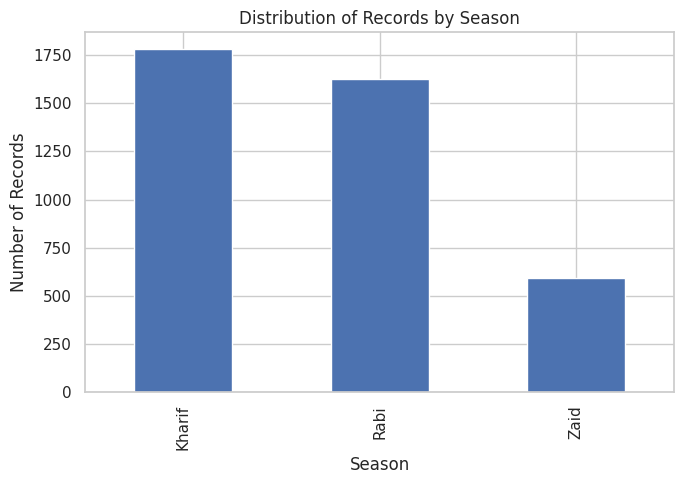

In [23]:
# Distribution of records by season

plt.figure(figsize=(7, 5))

df['Season'].value_counts().plot(
    kind='bar'
)

plt.title('Distribution of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

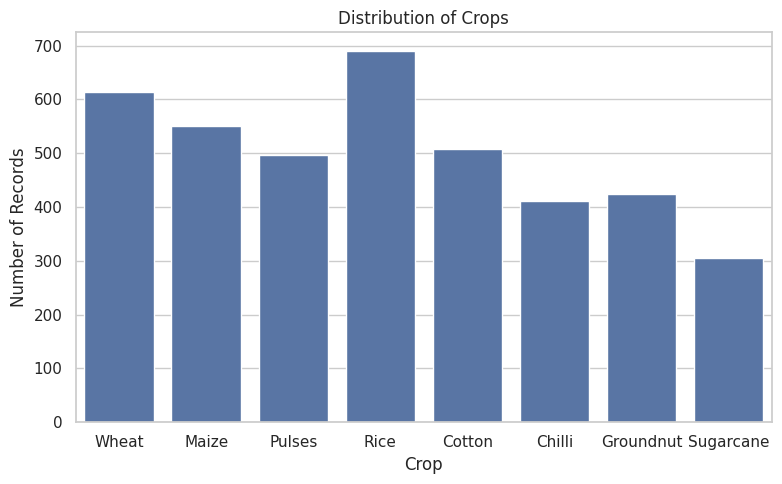

In [24]:
# Distribution of crops

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Crop'
)

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

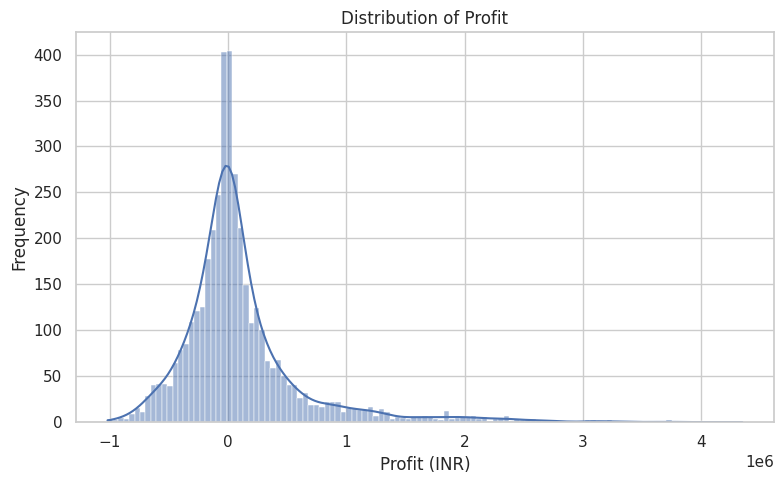

In [25]:
# Profit distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Profit_INR',
    kde=True
)

plt.title('Distribution of Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

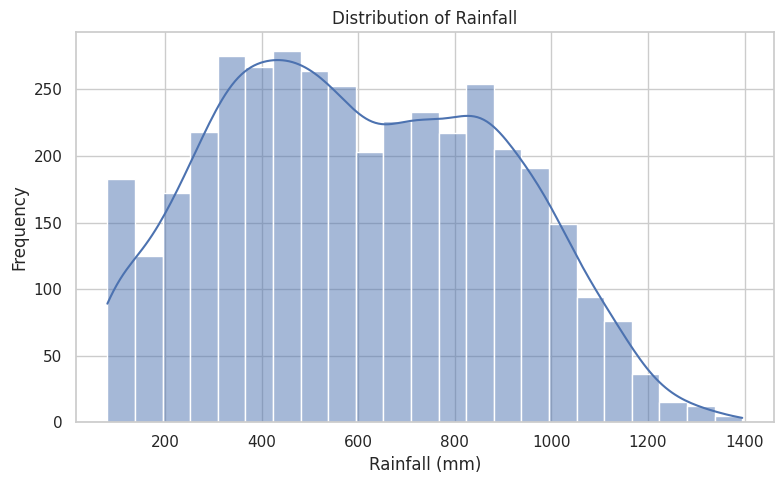

In [26]:
# Rainfall distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Rainfall_mm',
    kde=True
)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Outlier Analysis

Investigate potential outliers using statistical and visual methods.

Extreme values should not automatically be deleted.
They may represent:
• Data-entry problems
• Legitimate observations
• Situations requiring further investigation

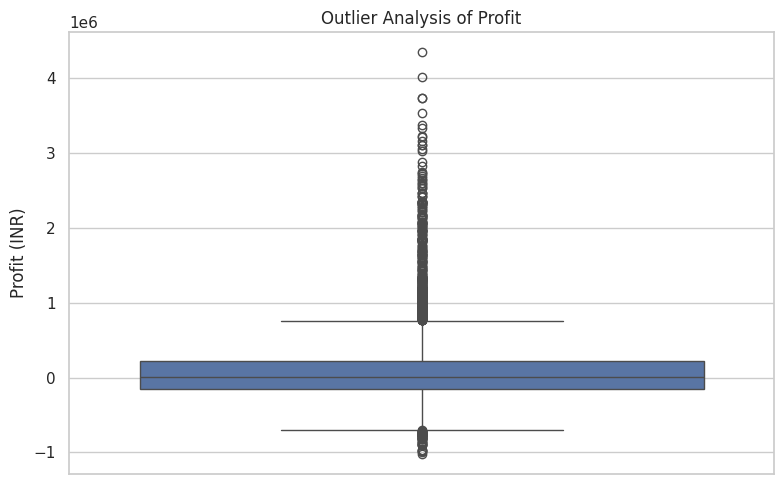

In [28]:
# Boxplot for Profit

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='Profit_INR'
)

plt.title('Outlier Analysis of Profit')

plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

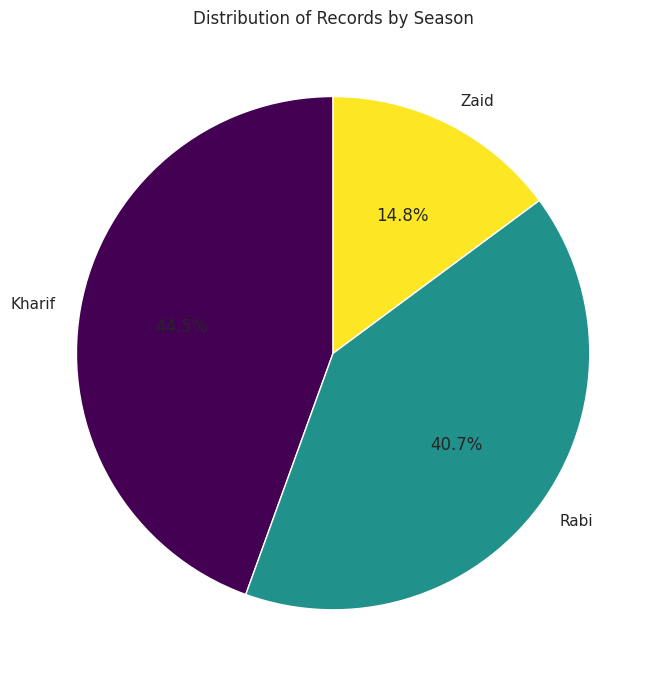

In [44]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('')  # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [45]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


In [46]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


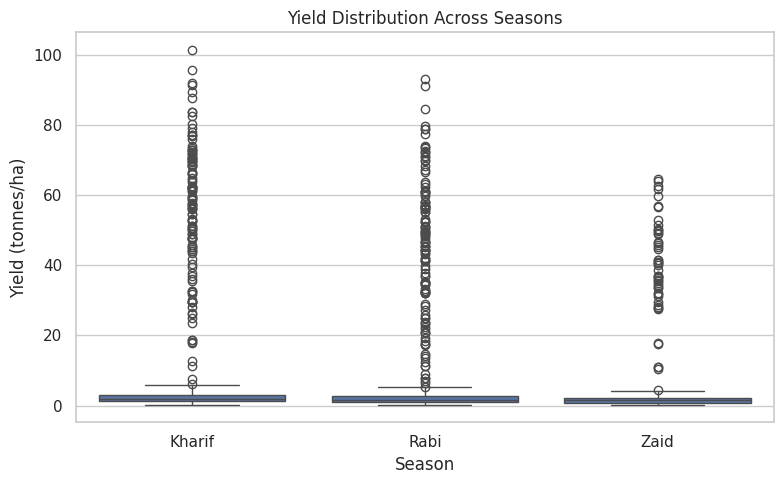

In [47]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

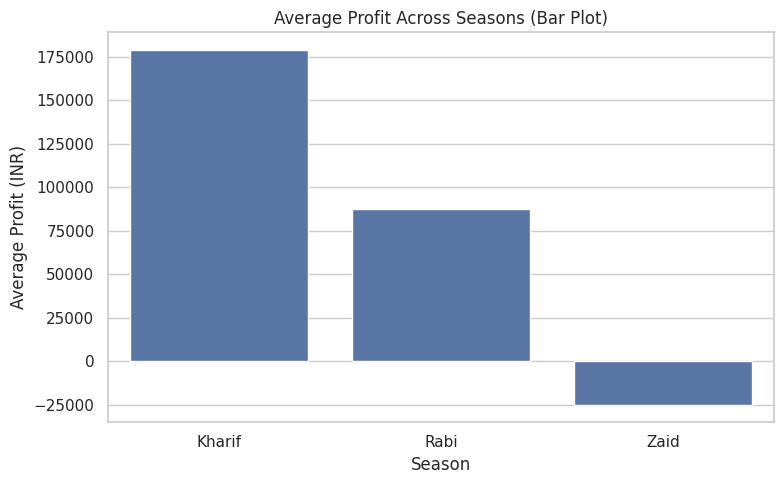

In [48]:
# Average Profit Across Seasons (Bar Plot)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

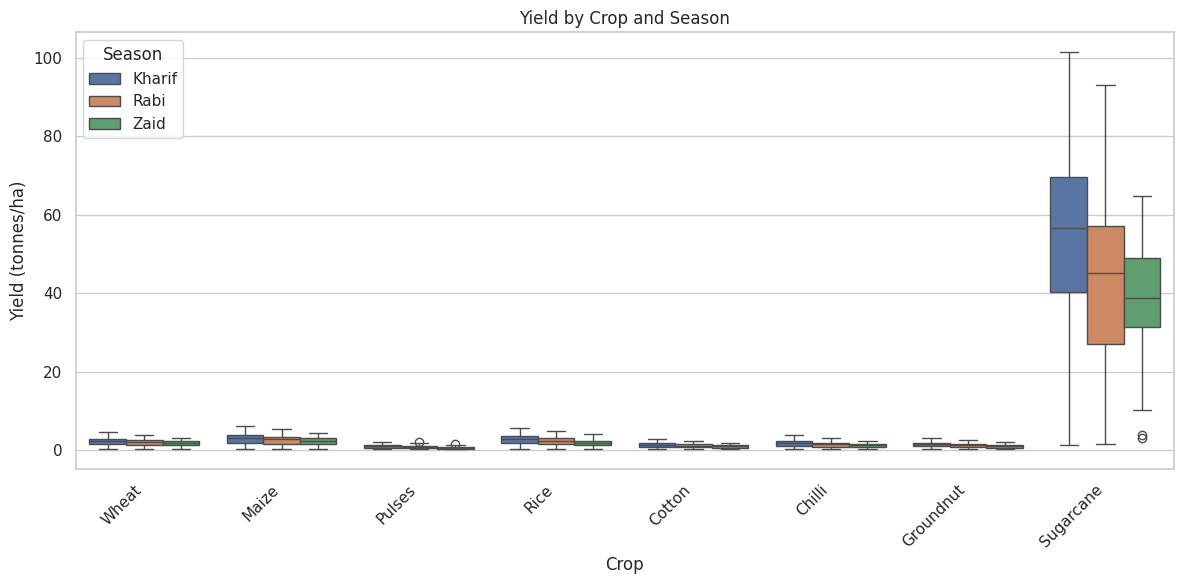

In [49]:


# Multivariate: Season, crop and yield
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

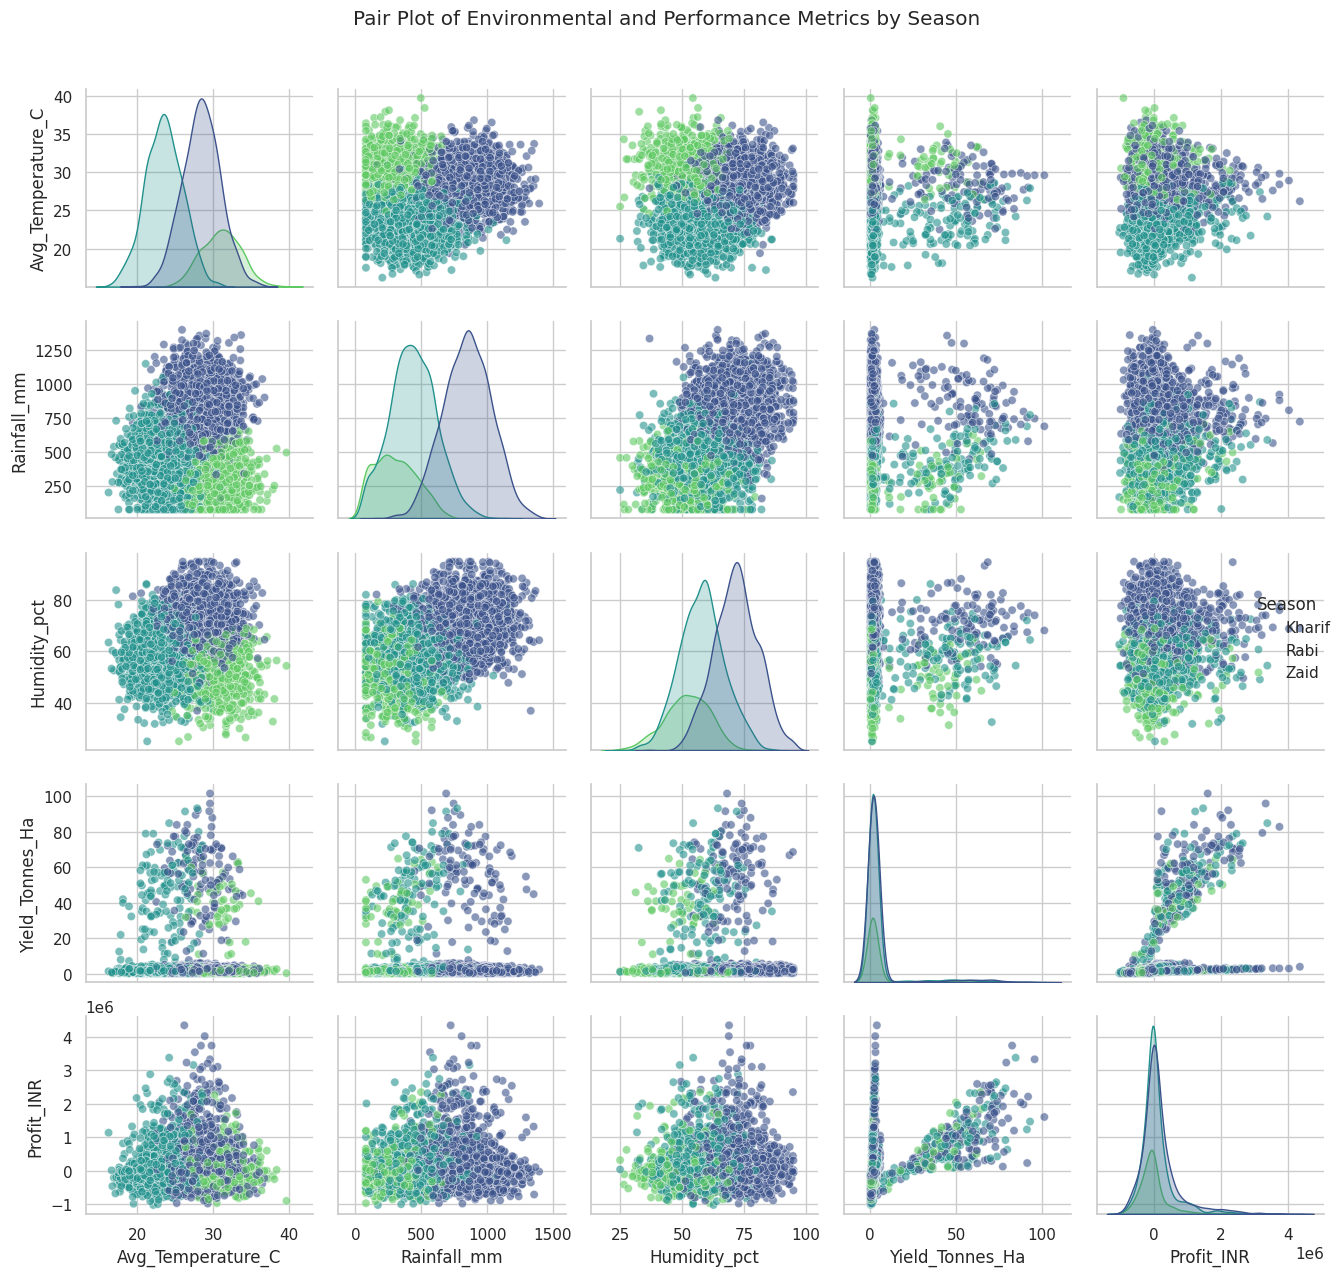

In [51]:
# Pair Plot of Key Environmental and Performance Metrics by Season
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

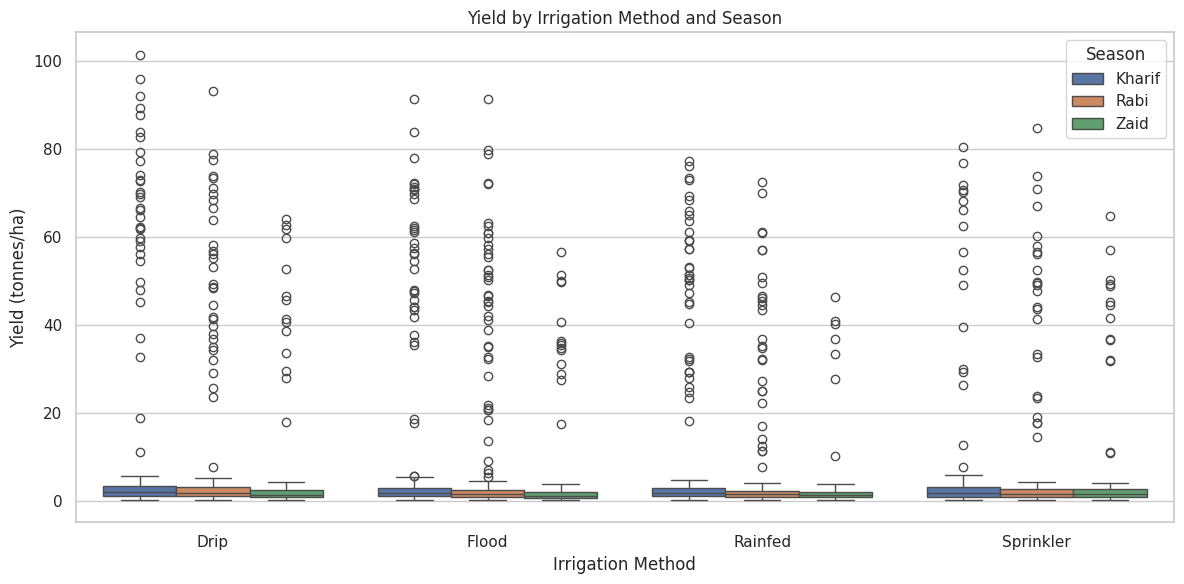

In [52]:
# Yield by Irrigation Method and Season
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

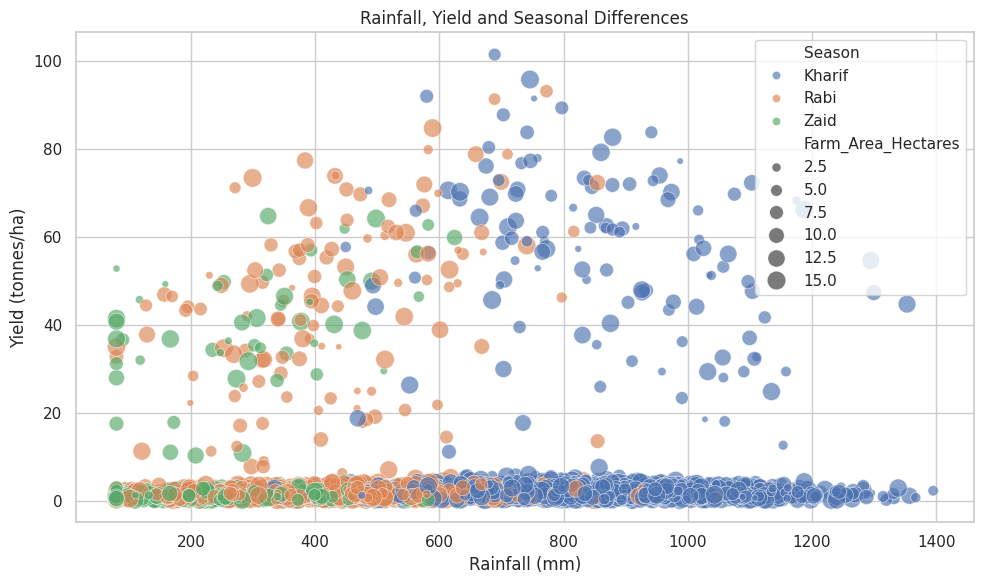

In [53]:
# Rainfall, Yield and Seasonal Differences
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

# Seasonal Comparison

In [58]:
# General seasonal summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


In [60]:
# Compare crop performance within each season
crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

# Additional Student-Driven Analysis
Three additional analyses are performed to explore regional
differences, crop-specific seasonal patterns, and resource usage.

These analyses are relevant because agricultural performance
can vary across locations, crops, seasons and resource-use
patterns.

Analysis 1: Regional Performance

In [67]:
regional_analysis = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2).sort_values('Profit_INR', ascending=False)

display(regional_analysis)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
State,,,,
Punjab,6.12,52.23,686225.70,136025.64
Maharashtra,5.02,43.98,650032.67,135428.86
Karnataka,5.69,47.73,653426.18,119422.34
Tamil Nadu,4.88,40.84,629093.42,117744.75
Gujarat,5.66,48.33,654692.86,117568.24
Telangana,5.04,39.25,628784.53,108829.62
Madhya Pradesh,4.99,37.56,597558.36,86840.76
Andhra Pradesh,4.63,36.91,606663.66,73453.53


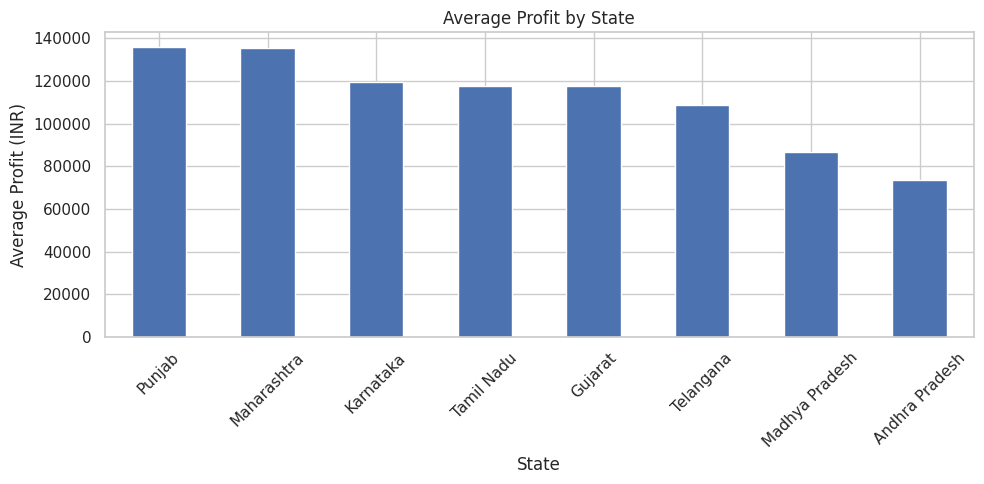

In [68]:
plt.figure(figsize=(10, 5))

regional_analysis['Profit_INR'].plot(kind='bar')

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Analysis 2: Crop × Season

In [69]:
crop_season_analysis = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

display(crop_season_analysis)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


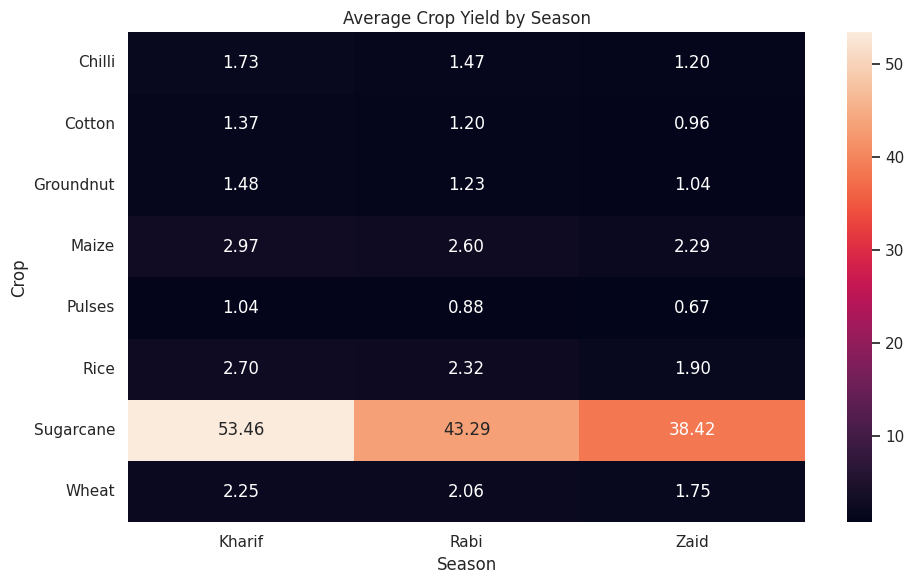

In [70]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_analysis,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

Analysis 3: Irrigation & Water Efficiency

In [71]:
resource_analysis = df.groupby('Irrigation_Method').agg({
    'Water_Used_m3': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).round(2).sort_values(
    'Water_Efficiency_t_per_1000m3',
    ascending=False
)

display(resource_analysis)

,Water_Used_m3,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Rainfed,3549.55,4.60,7.56,79050.37
Drip,5918.75,6.58,6.27,219626.00
Sprinkler,6208.26,5.16,4.67,91121.08
Flood,8026.47,4.86,3.44,73354.02


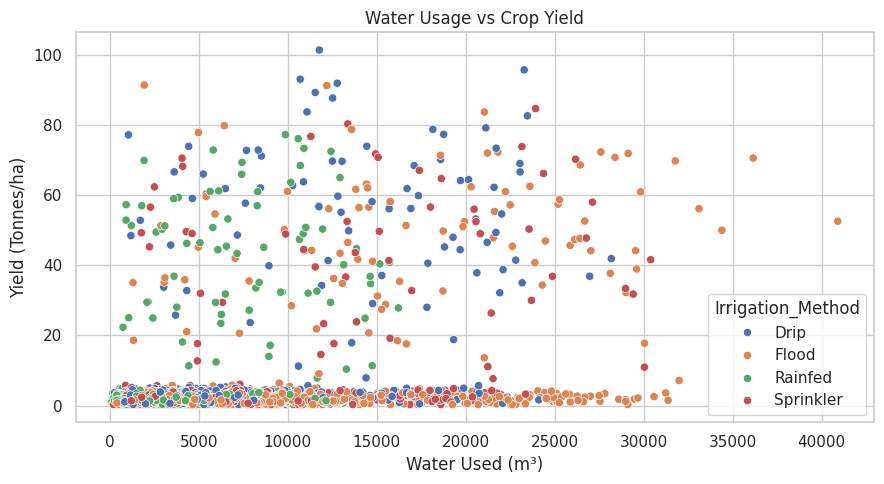

In [72]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method'
)

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/ha)')

plt.tight_layout()
plt.show()

# Key Insights

1. Observation:
The average agricultural performance differs across states.

Evidence:
The regional analysis shows differences in average yield,
revenue and profit between states.

Interpretation:
This indicates that agricultural performance varies by region.

Limitation:
The analysis does not establish that location itself causes
the observed differences.

2. Observation:
Crop yield varies across different seasons.

Evidence:
The crop-season heatmap shows different average yields for
different crop and season combinations.

Interpretation:
Some crop-season combinations show relatively higher yields.

Limitation:
The analysis does not prove that season alone causes the
difference in yield.

3. Observation:
Profit differs between agricultural regions.

Evidence:
The state-wise profit analysis shows variation in average profit.

Interpretation:
Economic performance is not uniform across the regions
represented in the dataset.

Limitation:
Other factors such as crop type, farm size and input costs
may also contribute to the differences.

4. Observation:
Irrigation methods show differences in water efficiency.

Evidence:
The irrigation analysis compares average water usage and
water efficiency across irrigation methods.

Interpretation:
Some irrigation methods appear more water-efficient in
the observed dataset.

Limitation:
The results should not be generalized to all agricultural
conditions without additional data.

5. Observation:
Water usage varies across farms and irrigation methods.

Evidence:
The resource usage analysis shows differences in average
water consumption.

Interpretation:
Resource requirements vary depending on the irrigation method
and farming conditions.

Limitation:
Water usage may also depend on farm size, crop and environmental
conditions.

6. Observation:
Rainfall and crop yield show an observable relationship.

Evidence:
The rainfall-versus-yield scatter plot shows the distribution
of yield across different rainfall levels.

Interpretation:
Rainfall may be associated with differences in agricultural
yield.

Limitation:
The relationship does not establish causation.

7. Observation:
Average profit differs between crop types.

Evidence:
The crop-wise profit analysis shows variation in average profit
among the crops.

Interpretation:
Some crops are economically stronger than others in this dataset.

Limitation:
Market conditions and production costs may influence these
differences.

8. Observation:
Agricultural performance contains variability and potential
outliers.

Evidence:
Boxplots and descriptive statistics show variation in yield,
profit and other numerical variables.

Interpretation:
Some observations are substantially different from the typical
values.

Limitation:
Extreme observations should not automatically be treated as
errors without investigating the underlying records.

# Recommendations

1. Compare regional agricultural performance before making
   region-specific decisions, because the dataset shows
   differences in average yield and profit across states.

2. Consider crop-season combinations when planning future
   agricultural analysis because yield varies across crops
   and seasons.

3. Investigate water-efficient irrigation methods further,
   since the dataset shows differences in water efficiency
   between irrigation methods.

4. Monitor water consumption together with crop yield rather
   than evaluating water usage independently.

5. Examine highly profitable crops and their associated
   production costs before making economic decisions.

6. Investigate unusual or extreme observations separately
   rather than automatically removing them.

7. Collect additional information such as soil quality,
   weather conditions, farm management practices and market
   prices to improve future analysis.

8. Use the current findings as exploratory evidence rather
   than as proof of causal relationships.

# Conclusion

The Seasonal Agriculture Performance Data Analysis project
examined agricultural performance across different crops,
seasons and regions.

The analysis included data cleaning, descriptive statistics,
univariate analysis, bivariate analysis, multivariate analysis,
outlier investigation and correlation analysis.

The results revealed differences in agricultural yield,
production, revenue and profit across crops, seasons and
regions. Additional analysis also showed variations in
resource usage and water efficiency between irrigation methods.

The crop-season analysis provided a useful comparison of
different crop and seasonal combinations, while regional
analysis helped identify differences in agricultural and
economic performance.

However, the findings represent associations within the
available dataset and should not be interpreted as proof of
causal relationships. Factors such as weather, soil conditions,
farm management, input costs and market conditions may also
influence agricultural outcomes.

Future analysis could use larger real-world datasets and
additional environmental, economic and farm-management
variables to develop stronger predictive and decision-support
models.

Overall, the project demonstrates how data analysis and
visualization can be used to explore seasonal agricultural
performance and identify useful patterns for further
investigation.

# Project Checklist

✓ Dataset loaded successfully

✓ Top 5 rows analyzed

✓ Dataset shape and structure examined

✓ Data types examined

✓ Missing values identified and handled

✓ Duplicate records identified and handled

✓ Descriptive/statistical analysis performed

✓ Outliers investigated

✓ Univariate analysis completed

✓ Bivariate analysis completed

✓ Multivariate analysis completed

✓ Correlation analysis completed

✓ Seasonal comparisons performed

✓ Regional performance analysis completed

✓ Crop-specific seasonal analysis completed

✓ Resource usage analysis completed

✓ At least 8 meaningful insights documented

✓ Evidence-based recommendations provided

✓ Limitations discussed

✓ Final conclusion provided